In [1]:
from fastai.vision.all import *
from fastbook import *

In [2]:
path = untar_data(URLs.MNIST_SAMPLE)
dls = ImageDataLoaders.from_folder(path)

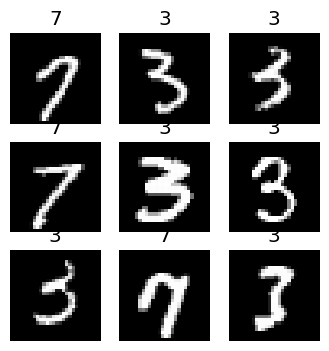

In [3]:
dls.show_batch(max_n=9, figsize=(4,4))

In [4]:
learn = vision_learner(dls, resnet18, pretrained=False,
                       loss_func=F.cross_entropy, metrics=accuracy)
epoch, lr = 1, 1e-1
learn.fit_one_cycle(epoch, lr)

epoch,train_loss,valid_loss,accuracy,time
0,0.167123,0.049859,0.995093,00:04


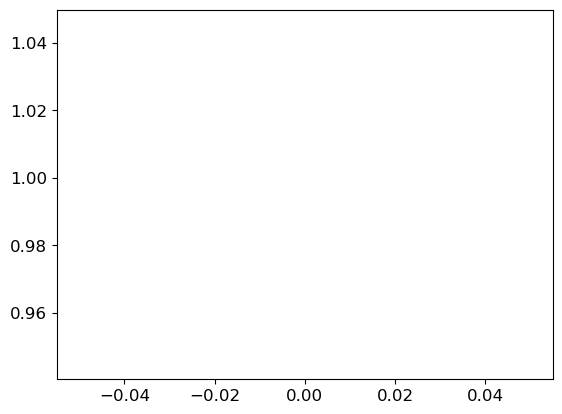

In [5]:
plt.plot(L(learn.recorder.values).itemgot(2));

## All 10 digits

In [6]:
path = untar_data(URLs.MNIST)

def getdls(bs=64):
    return DataBlock(
        # blocks=(ImageBlock(cls=PILImageBW), CategoryBlock),
        blocks=(ImageBlock(cls=PILImage), CategoryBlock),
        get_items=get_image_files,
        splitter=GrandparentSplitter('training', 'testing'),
        get_y=parent_label,
        batch_tfms=Normalize()
    ).dataloaders(path, bs=bs)

dls = getdls(bs=256)

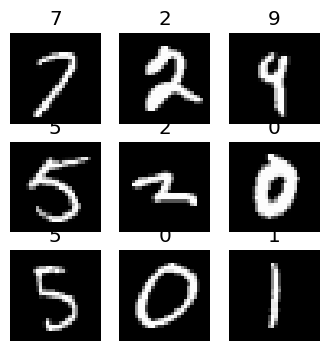

In [7]:
dls.show_batch(max_n=9, figsize=(4,4))

In [12]:
learn = vision_learner(dls, resnet18, pretrained=False,
                    loss_func=F.cross_entropy, metrics=accuracy)
learn.fit_one_cycle(1, 0.1)

epoch,train_loss,valid_loss,accuracy,time
0,0.101645,0.039568,0.987700,00:16


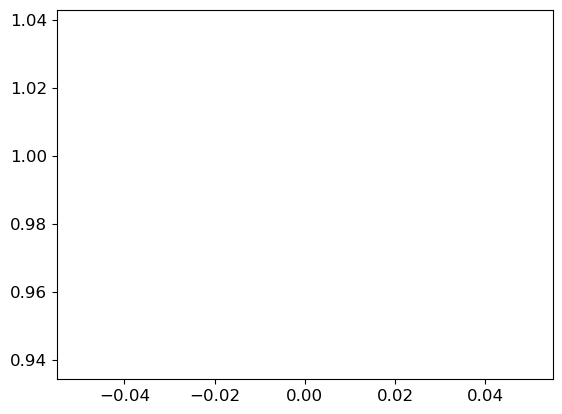

In [9]:
plt.plot(L(learn.recorder.values).itemgot(2));

## answer

In [10]:
# from fastai.vision.all import *
# from fastbook import *

# path = untar_data(URLs.MNIST)
# path.ls()
# path_train = path/'training'
# path_valid = path/'testing'

# train_x = get_image_files(path_train).sorted()
# train_x = [(tensor(Image.open(element)).float()) / 255 for element in train_x ]
# train_x = torch.stack(train_x).view(-1,28*28)
# train_y = [int(element.parent.name) for element in get_image_files(path_train).sorted()]
# train_y = tensor(train_y)

# dl = DataLoader(list(zip(train_x,train_y)),batch_size=256,shuffle=True)

# valid_x = get_image_files(path_valid).sorted()
# valid_x = [(tensor(Image.open(element)).float()) / 255 for element in valid_x ]
# valid_x = torch.stack(valid_x).view(-1,28*28)
# valid_y = [int(element.parent.name) for element in get_image_files(path_valid).sorted()]
# valid_y = tensor(valid_y)

# dl_valid = DataLoader(list(zip(valid_x,valid_y)),batch_size=256,shuffle=True)

# dls = DataLoaders(dl,dl_valid)

# simple_net = nn.Sequential(
#     nn.Linear(28*28,50),
#     nn.ReLU(),
#     nn.Linear(50,10)
# )

# learner = Learner(dls,simple_net,opt_func=SGD,loss_func=nn.CrossEntropyLoss(),metrics=accuracy,lr=0.001)
# learner.fit(10,0.1)

In [11]:
# plt.plot(L(learner.recorder.values).itemgot(2))